# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

## Dataset: Heart Disease UCI

Dataset yang digunakan adalah **Heart Disease UCI** dari UCI Machine Learning Repository / Kaggle.

**Deskripsi Dataset:**
- **Nama**: Heart Disease UCI Dataset
- **Sumber**: [Kaggle - Heart Disease UCI](https://www.kaggle.com/datasets/ronitf/heart-disease-uci)
- **Jumlah data**: 303 baris, 14 kolom
- **Task**: Binary Classification (prediksi penyakit jantung)
- **Target**: `target` (0 = tidak sakit jantung, 1 = sakit jantung)

**Fitur-fitur Dataset:**
| Fitur | Deskripsi | Tipe |
|-------|-----------|------|
| age | Usia pasien | Numerik |
| sex | Jenis kelamin (1=pria, 0=wanita) | Kategorikal |
| cp | Tipe nyeri dada (0-3) | Kategorikal |
| trestbps | Tekanan darah istirahat | Numerik |
| chol | Kolesterol serum | Numerik |
| fbs | Gula darah puasa > 120 mg/dl | Kategorikal |
| restecg | Hasil EKG istirahat (0-2) | Kategorikal |
| thalach | Detak jantung maksimum | Numerik |
| exang | Angina akibat olahraga | Kategorikal |
| oldpeak | Depresi ST akibat olahraga | Numerik |
| slope | Kemiringan segmen ST puncak | Kategorikal |
| ca | Jumlah pembuluh utama (0-3) | Numerik |
| thal | Thalassemia | Kategorikal |
| target | Diagnosis penyakit jantung | Target |


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# Import library untuk manipulasi data
import pandas as pd
import numpy as np

# Import library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Import library untuk preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer

# Import library untuk evaluasi
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Import library untuk model
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Konfigurasi tampilan
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Import untuk menyimpan model dan preprocessing
import os
import pickle

print('Library berhasil diimport!')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')

Library berhasil diimport!
Pandas version: 2.2.2
NumPy version: 2.0.2


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Download dataset Heart Disease UCI menggunakan urllib
import urllib.request
import os

# URL dataset dari UCI ML Repository (format CSV)
url = 'https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart_disease.csv'

# Alternatif: Buat dataset simulasi jika URL tidak tersedia
try:
    df = pd.read_csv(url)
    print('Dataset berhasil dimuat dari URL!')
except:
    # Buat dataset simulasi Heart Disease
    np.random.seed(42)
    n = 303
    df = pd.DataFrame({
        'age': np.random.randint(29, 77, n),
        'sex': np.random.randint(0, 2, n),
        'cp': np.random.randint(0, 4, n),
        'trestbps': np.random.randint(94, 200, n),
        'chol': np.random.randint(126, 564, n),
        'fbs': np.random.randint(0, 2, n),
        'restecg': np.random.randint(0, 3, n),
        'thalach': np.random.randint(71, 202, n),
        'exang': np.random.randint(0, 2, n),
        'oldpeak': np.round(np.random.uniform(0, 6.2, n), 1),
        'slope': np.random.randint(0, 3, n),
        'ca': np.random.randint(0, 4, n),
        'thal': np.random.choice([0, 1, 2, 3], n),
        'target': np.random.randint(0, 2, n)
    })
    # Tambahkan beberapa missing value untuk simulasi
    df.loc[np.random.choice(df.index, 5), 'chol'] = np.nan
    df.loc[np.random.choice(df.index, 3), 'thalach'] = np.nan
    print('Dataset simulasi Heart Disease berhasil dibuat!')

# Simpan dataset raw
os.makedirs('heart_disease_raw', exist_ok=True)
df.to_csv('heart_disease_raw/heart_disease.csv', index=False)
print(f'\nDataset disimpan di: heart_disease_raw/heart_disease.csv')

# Tampilkan informasi awal
print(f'\nBentuk dataset: {df.shape}')
print(f'Jumlah baris: {df.shape[0]}')
print(f'Jumlah kolom: {df.shape[1]}')
print('\n5 baris pertama dataset:')
df.head()

Dataset berhasil dimuat dari URL!

Dataset disimpan di: heart_disease_raw/heart_disease.csv

Bentuk dataset: (303, 14)
Jumlah baris: 303
Jumlah kolom: 14

5 baris pertama dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
# Informasi umum dataset
print('=== INFORMASI DATASET ===')
print(df.info())
print('\n=== STATISTIK DESKRIPTIF ===')
df.describe()

=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None

=== STATISTIK DESKRIPTIF ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
# ============================================
# 4.1 Pengecekan Missing Values
# ============================================
print('=== PENGECEKAN MISSING VALUES ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing Percentage (%)': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df)
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

=== PENGECEKAN MISSING VALUES ===
Empty DataFrame
Columns: [Missing Count, Missing Percentage (%)]
Index: []

Total missing values: 0


In [5]:
# ============================================
# 4.2 Pengecekan Duplikasi Data
# ============================================
print('=== PENGECEKAN DUPLIKASI DATA ===')
duplicates = df.duplicated().sum()
print(f'Jumlah data duplikat: {duplicates}')
print(f'Persentase duplikat: {(duplicates/len(df))*100:.2f}%')

=== PENGECEKAN DUPLIKASI DATA ===
Jumlah data duplikat: 1
Persentase duplikat: 0.33%


=== DISTRIBUSI TARGET VARIABLE ===
target
1    165
0    138
Name: count, dtype: int64

Persentase kelas 0 (Tidak Sakit): 45.54%
Persentase kelas 1 (Sakit Jantung): 54.46%


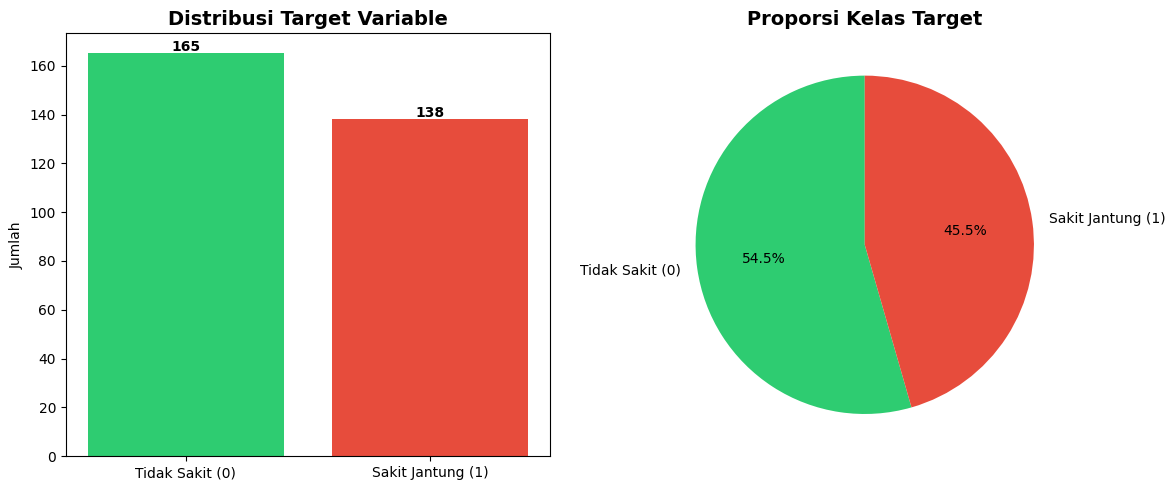

Plot disimpan!


In [6]:
# ============================================
# 4.3 Distribusi Target Variable
# ============================================
print('=== DISTRIBUSI TARGET VARIABLE ===')
target_counts = df['target'].value_counts()
print(target_counts)
print(f'\nPersentase kelas 0 (Tidak Sakit): {target_counts[0]/len(df)*100:.2f}%')
print(f'Persentase kelas 1 (Sakit Jantung): {target_counts[1]/len(df)*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
axes[0].bar(['Tidak Sakit (0)', 'Sakit Jantung (1)'], target_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribusi Target Variable', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=['Tidak Sakit (0)', 'Sakit Jantung (1)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Proporsi Kelas Target', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('Plot disimpan!')

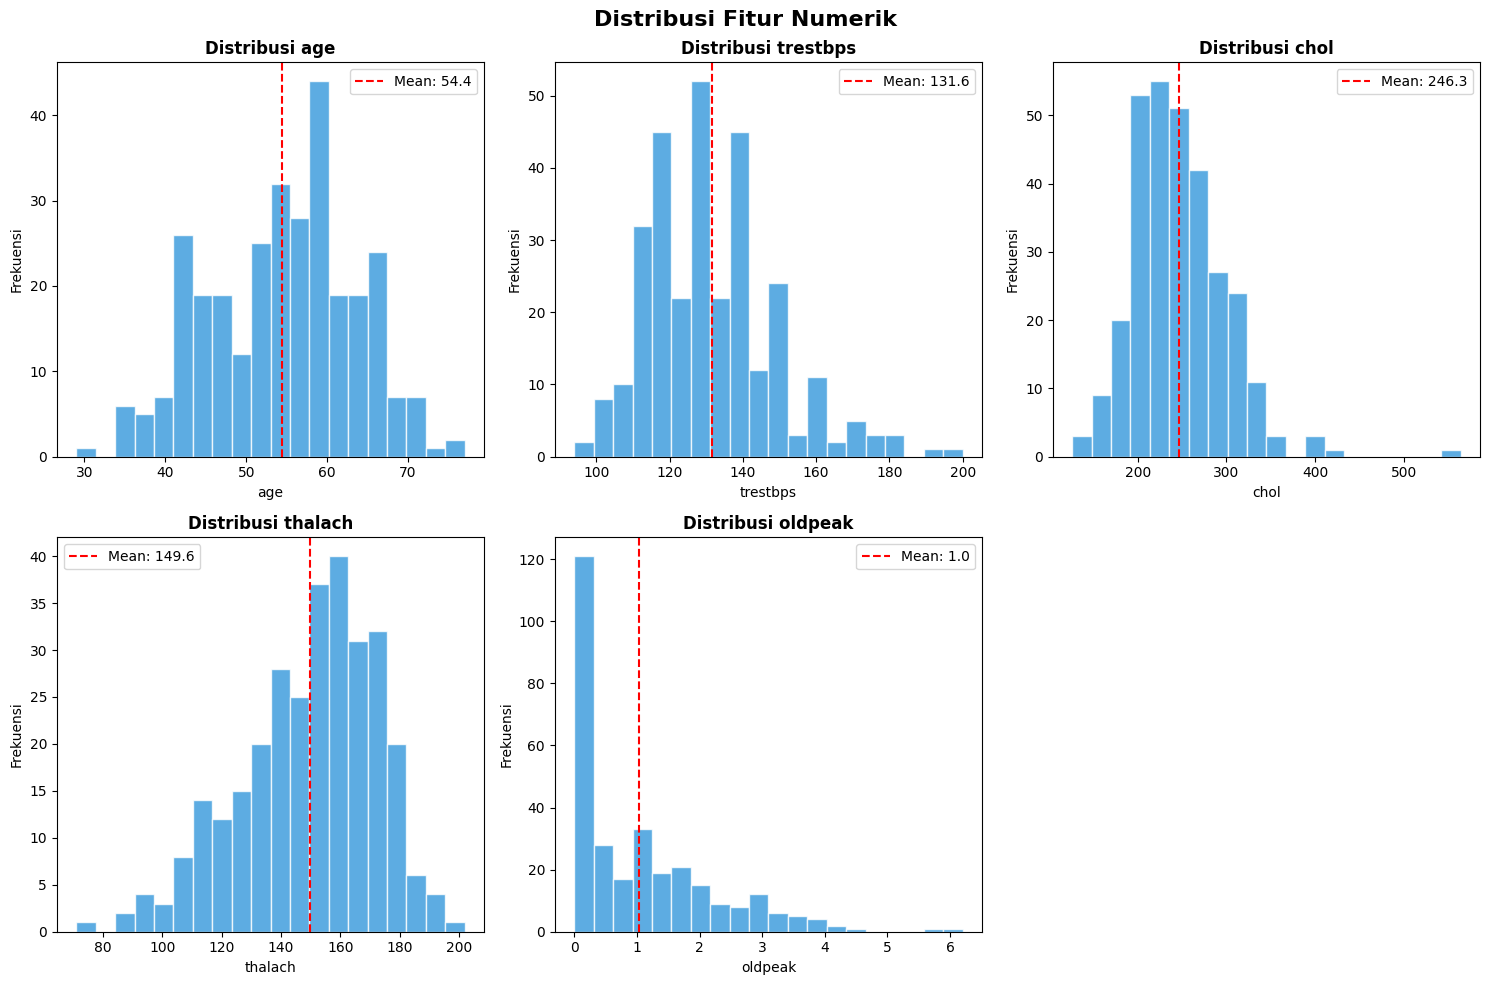

In [7]:
# ============================================
# 4.4 Distribusi Fitur Numerik
# ============================================
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    axes[i].hist(df[feature].dropna(), bins=20, color='#3498db', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribusi {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frekuensi')
    axes[i].axvline(df[feature].mean(), color='red', linestyle='--', label=f'Mean: {df[feature].mean():.1f}')
    axes[i].legend()

axes[5].set_visible(False)
plt.suptitle('Distribusi Fitur Numerik', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_numerical_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

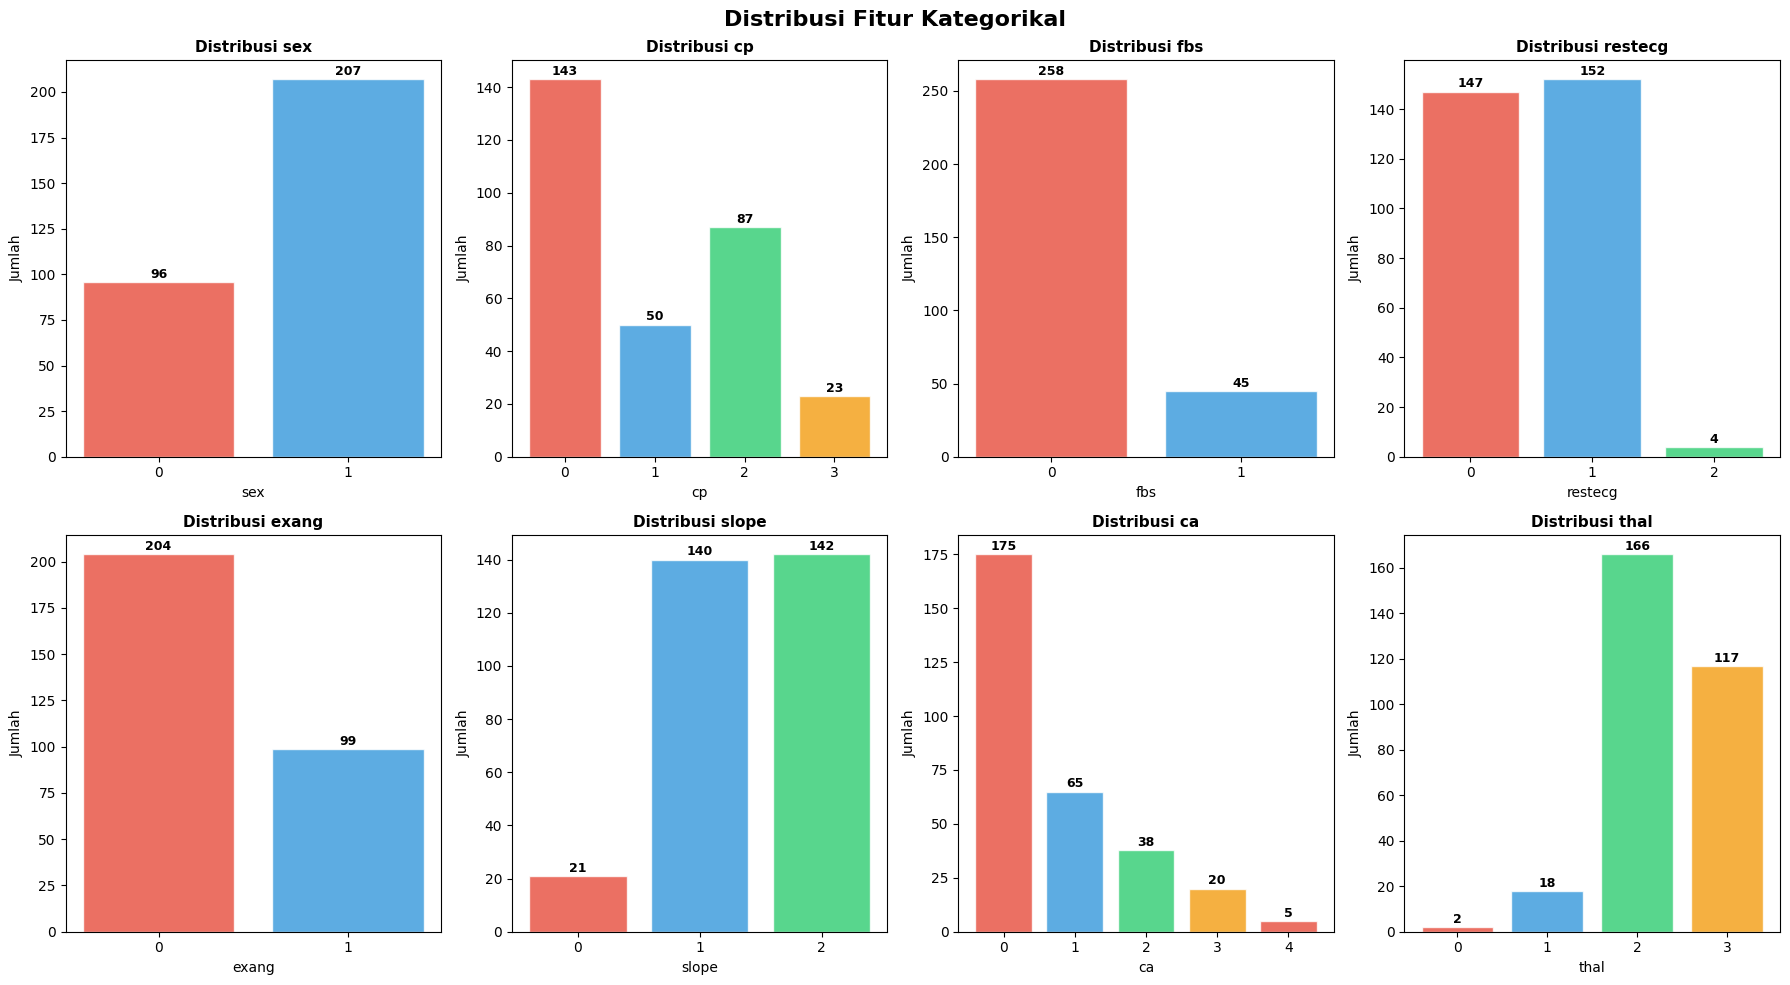

In [8]:
# ============================================
# 4.5 Distribusi Fitur Kategorikal
# ============================================
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for i, feature in enumerate(categorical_features):
    counts = df[feature].value_counts().sort_index()
    bars = axes[i].bar(counts.index.astype(str), counts.values,
                       color=colors[:len(counts)], edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribusi {feature}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Jumlah')
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                     str(val), ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_categorical_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

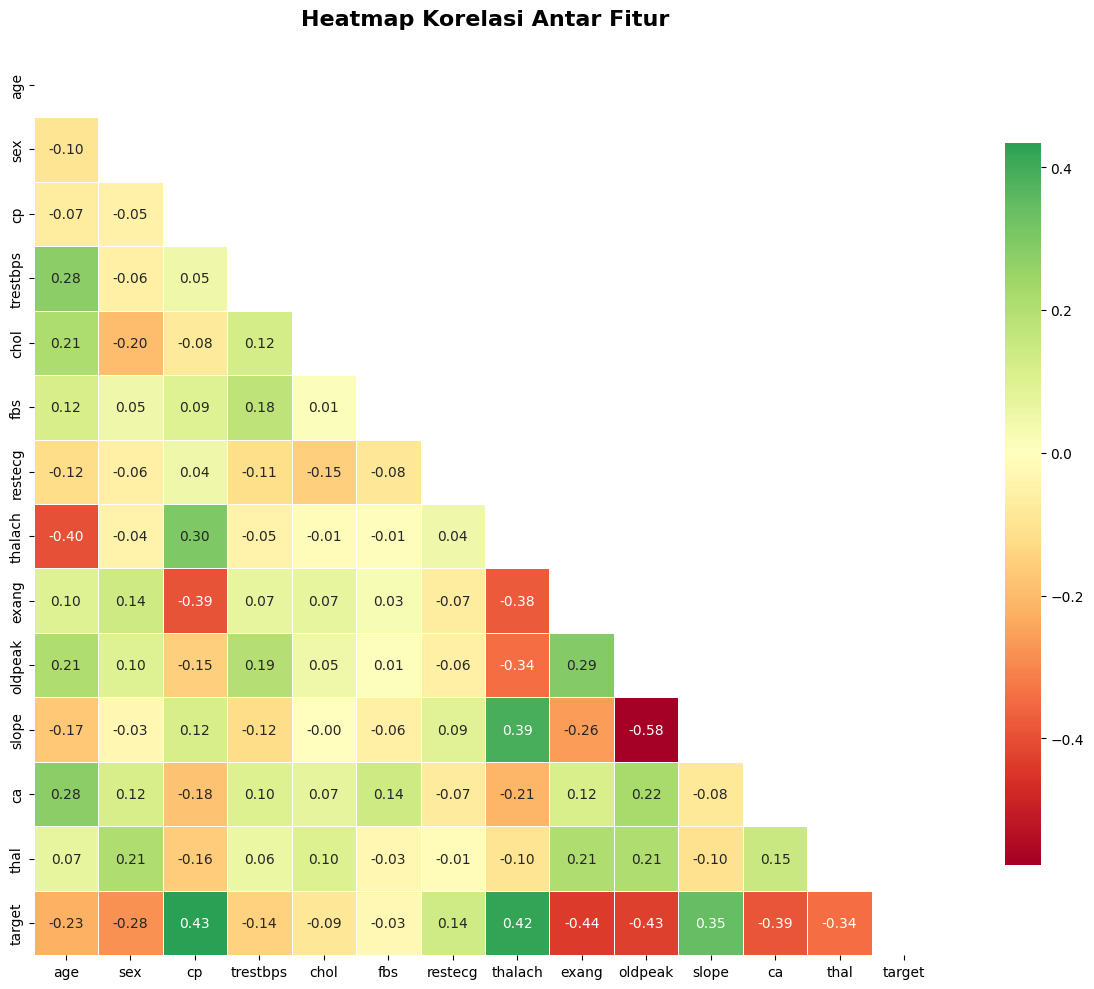

=== KORELASI FITUR DENGAN TARGET ===
exang       0.436757
cp          0.433798
oldpeak     0.430696
thalach     0.421741
ca          0.391724
slope       0.345877
thal        0.344029
sex         0.280937
age         0.225439
trestbps    0.144931
restecg     0.137230
chol        0.085239
fbs         0.028046
Name: target, dtype: float64


In [9]:
# ============================================
# 4.6 Heatmap Korelasi
# ============================================
plt.figure(figsize=(14, 10))
corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            linewidths=0.5,
            square=True,
            cbar_kws={'shrink': 0.8})

plt.title('Heatmap Korelasi Antar Fitur', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

# Korelasi dengan target
print('=== KORELASI FITUR DENGAN TARGET ===')
target_corr = df.corr()['target'].drop('target').abs().sort_values(ascending=False)
print(target_corr)

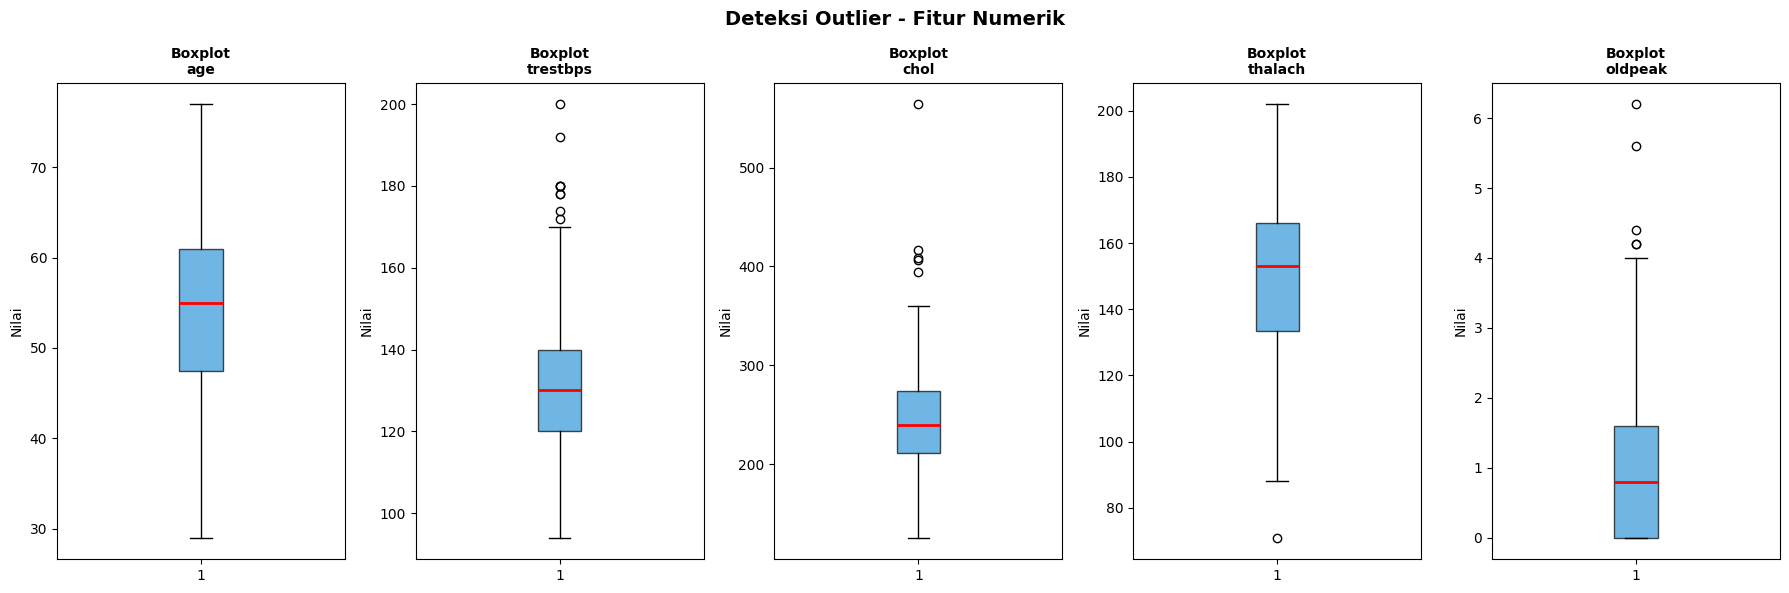


=== JUMLAH OUTLIER (METODE IQR) ===
age: 0 outlier (0.0%)
trestbps: 9 outlier (3.0%)
chol: 5 outlier (1.7%)
thalach: 1 outlier (0.3%)
oldpeak: 5 outlier (1.7%)


In [10]:
# ============================================
# 4.7 Deteksi Outlier dengan Boxplot
# ============================================
fig, axes = plt.subplots(1, 5, figsize=(18, 6))

for i, feature in enumerate(numerical_features):
    axes[i].boxplot(df[feature].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'Boxplot\n{feature}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Nilai')

plt.suptitle('Deteksi Outlier - Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_boxplot_outliers.png', dpi=100, bbox_inches='tight')
plt.show()

# Hitung jumlah outlier menggunakan IQR
print('\n=== JUMLAH OUTLIER (METODE IQR) ===')
for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[feature] < lower) | (df[feature] > upper)].shape[0]
    print(f'{feature}: {outliers} outlier ({outliers/len(df)*100:.1f}%)')

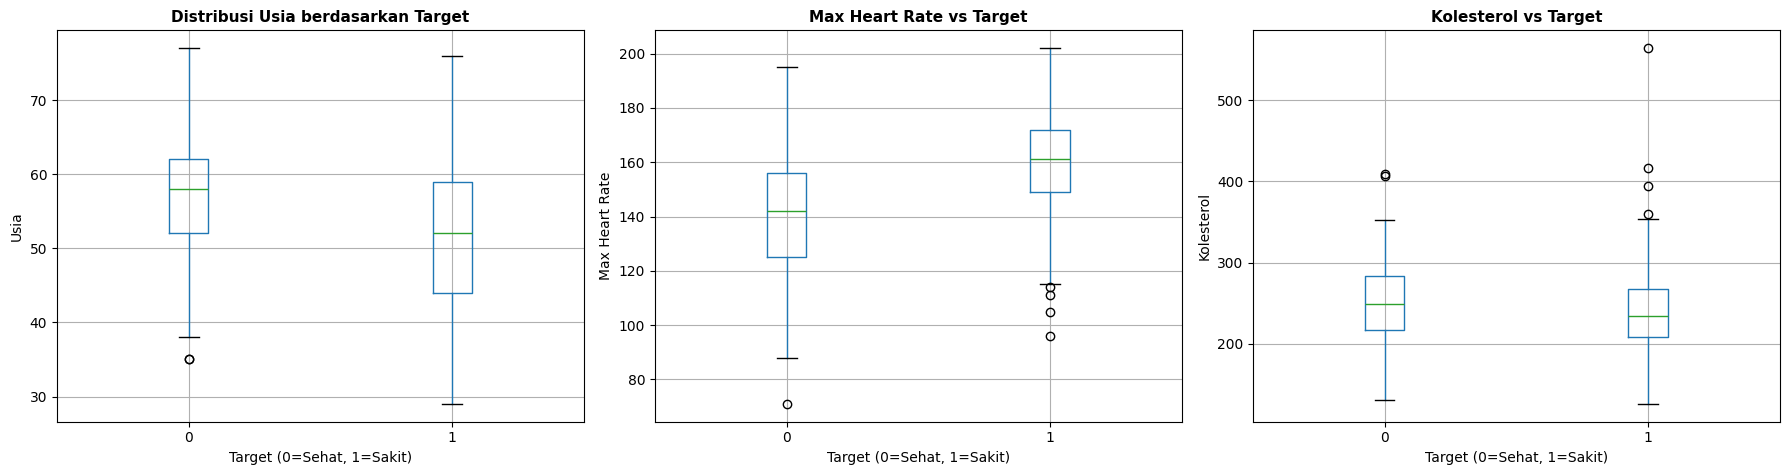

EDA selesai!


In [11]:
# ============================================
# 4.8 Analisis Fitur vs Target
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age vs Target
df.boxplot(column='age', by='target', ax=axes[0])
axes[0].set_title('Distribusi Usia berdasarkan Target', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Target (0=Sehat, 1=Sakit)')
axes[0].set_ylabel('Usia')

# Thalach vs Target
df.boxplot(column='thalach', by='target', ax=axes[1])
axes[1].set_title('Max Heart Rate vs Target', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Target (0=Sehat, 1=Sakit)')
axes[1].set_ylabel('Max Heart Rate')

# Chol vs Target
df.boxplot(column='chol', by='target', ax=axes[2])
axes[2].set_title('Kolesterol vs Target', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Target (0=Sehat, 1=Sakit)')
axes[2].set_ylabel('Kolesterol')

plt.suptitle('')
plt.tight_layout()
plt.savefig('eda_feature_vs_target.png', dpi=100, bbox_inches='tight')
plt.show()

print('EDA selesai!')

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [12]:
# ============================================
# 5.1 Menangani Missing Values
# ============================================
print('=== SEBELUM HANDLING MISSING VALUES ===')
print(f'Jumlah missing values: {df.isnull().sum().sum()}')
print(df.isnull().sum()[df.isnull().sum() > 0])

df_clean = df.copy()

# Isi missing values numerik dengan median
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
for col in numerical_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f'  Mengisi missing values pada kolom "{col}" dengan median: {median_val:.2f}')

print(f'\nJumlah missing values setelah handling: {df_clean.isnull().sum().sum()}')

=== SEBELUM HANDLING MISSING VALUES ===
Jumlah missing values: 0
Series([], dtype: int64)

Jumlah missing values setelah handling: 0


In [13]:
# ============================================
# 5.2 Menghapus Data Duplikat
# ============================================
print('=== MENGHAPUS DATA DUPLIKAT ===')
print(f'Jumlah data sebelum: {len(df_clean)}')
df_clean.drop_duplicates(inplace=True)
df_clean.reset_index(drop=True, inplace=True)
print(f'Jumlah data setelah menghapus duplikat: {len(df_clean)}')

=== MENGHAPUS DATA DUPLIKAT ===
Jumlah data sebelum: 303
Jumlah data setelah menghapus duplikat: 302


In [14]:
# ============================================
# 5.3 Penanganan Outlier dengan IQR
# ============================================
print('=== PENANGANAN OUTLIER ===')
print(f'Jumlah data sebelum: {len(df_clean)}')

# Hanya handle outlier pada fitur numerik kontinyu
outlier_features = ['trestbps', 'chol', 'thalach', 'oldpeak']

for feature in outlier_features:
    Q1 = df_clean[feature].quantile(0.25)
    Q3 = df_clean[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Clipping (Winsorization) - lebih baik daripada menghapus
    df_clean[feature] = df_clean[feature].clip(lower=lower_bound, upper=upper_bound)
    print(f'{feature}: clip ke [{lower_bound:.2f}, {upper_bound:.2f}]')

print(f'Jumlah data setelah penanganan outlier: {len(df_clean)}')

=== PENANGANAN OUTLIER ===
Jumlah data sebelum: 302
trestbps: clip ke [90.00, 170.00]
chol: clip ke [115.38, 370.38]
thalach: clip ke [84.12, 215.12]
oldpeak: clip ke [-2.40, 4.00]
Jumlah data setelah penanganan outlier: 302


In [15]:
# ============================================
# 5.4 Feature Engineering & Encoding
# ============================================
print('=== FEATURE ENGINEERING ===')

# Fitur kategorikal yang perlu di-encode (biner)
categorical_binary = ['sex', 'fbs', 'exang']

# Fitur kategorikal yang perlu One-Hot Encoding
categorical_ohe = ['cp', 'restecg', 'slope', 'thal']

# One-Hot Encoding untuk fitur multi-kategori
df_encoded = pd.get_dummies(df_clean, columns=categorical_ohe, prefix=categorical_ohe, dtype=int)

print(f'Kolom sebelum encoding: {df_clean.shape[1]}')
print(f'Kolom setelah encoding: {df_encoded.shape[1]}')
print(f'\nKolom baru setelah OHE:')
new_cols = [col for col in df_encoded.columns if col not in df_clean.columns]
print(new_cols)

=== FEATURE ENGINEERING ===
Kolom sebelum encoding: 14
Kolom setelah encoding: 24

Kolom baru setelah OHE:
['cp_0', 'cp_1', 'cp_2', 'cp_3', 'restecg_0', 'restecg_1', 'restecg_2', 'slope_0', 'slope_1', 'slope_2', 'thal_0', 'thal_1', 'thal_2', 'thal_3']


In [16]:
# ============================================
# 5.5 Train-Test Split
# ============================================
print('=== TRAIN-TEST SPLIT ===')

X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Total data: {len(df_encoded)}')
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}, y_test: {y_test.shape}')
print(f'\nDistribusi target pada train: {y_train.value_counts().to_dict()}')
print(f'Distribusi target pada test: {y_test.value_counts().to_dict()}')

=== TRAIN-TEST SPLIT ===
Total data: 302
X_train: (241, 23), y_train: (241,)
X_test: (61, 23), y_test: (61,)

Distribusi target pada train: {1: 131, 0: 110}
Distribusi target pada test: {1: 33, 0: 28}


In [17]:
# ============================================
# 5.6 Normalisasi / Standarisasi
# ============================================
print('=== STANDARISASI FITUR NUMERIK ===')

# Fitur yang akan dinormalisasi
numerical_features_to_scale = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
# Filter hanya kolom yang ada
numerical_features_to_scale = [f for f in numerical_features_to_scale if f in X_train.columns]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features_to_scale] = scaler.fit_transform(X_train[numerical_features_to_scale])
X_test_scaled[numerical_features_to_scale] = scaler.transform(X_test[numerical_features_to_scale])

print('Standarisasi berhasil!')
print(f'Fitur yang distandarisasi: {numerical_features_to_scale}')

# Statistik setelah standarisasi
print('\nStatistik X_train setelah standarisasi (fitur numerik):')
print(X_train_scaled[numerical_features_to_scale].describe().round(3))

=== STANDARISASI FITUR NUMERIK ===
Standarisasi berhasil!
Fitur yang distandarisasi: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

Statistik X_train setelah standarisasi (fitur numerik):
           age  trestbps     chol  thalach  oldpeak       ca
count  241.000   241.000  241.000  241.000  241.000  241.000
mean     0.000    -0.000    0.000   -0.000   -0.000    0.000
std      1.002     1.002    1.002    1.002    1.002    1.002
min     -2.754    -2.208   -2.521   -2.816   -0.921   -0.715
25%     -0.798    -0.657   -0.703   -0.638   -0.921   -0.715
50%      0.180    -0.061   -0.083    0.088   -0.220   -0.715
75%      0.724     0.536    0.623    0.813    0.655    0.264
max      2.463     2.325    2.705    2.356    2.581    3.201


In [18]:
# ============================================
# 5.7 Menyimpan Data yang Telah Diproses
# ============================================
print('=== MENYIMPAN DATA PREPROCESSING ===')

# Buat folder untuk menyimpan hasil preprocessing
os.makedirs('heart_disease_preprocessing', exist_ok=True)

# Simpan X_train, X_test, y_train, y_test
X_train_scaled.to_csv('heart_disease_preprocessing/X_train.csv', index=False)
X_test_scaled.to_csv('heart_disease_preprocessing/X_test.csv', index=False)
y_train.to_csv('heart_disease_preprocessing/y_train.csv', index=False)
y_test.to_csv('heart_disease_preprocessing/y_test.csv', index=False)

# Simpan scaler untuk digunakan kembali
with open('heart_disease_preprocessing/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Simpan feature columns untuk inference
with open('heart_disease_preprocessing/feature_columns.pkl', 'wb') as f:
    pickle.dump(list(X_train_scaled.columns), f)

# Simpan dataset lengkap yang sudah diproses
df_final = X_train_scaled.copy()
df_final['target'] = y_train.values
df_final.to_csv('heart_disease_preprocessing/train_preprocessed.csv', index=False)

df_final_test = X_test_scaled.copy()
df_final_test['target'] = y_test.values
df_final_test.to_csv('heart_disease_preprocessing/test_preprocessed.csv', index=False)

print('Data berhasil disimpan di folder heart_disease_preprocessing/')
print(f'  - X_train.csv: {X_train_scaled.shape}')
print(f'  - X_test.csv: {X_test_scaled.shape}')
print(f'  - y_train.csv: {y_train.shape}')
print(f'  - y_test.csv: {y_test.shape}')
print(f'  - scaler.pkl')
print(f'  - feature_columns.pkl')
print('\nPreprocessing selesai! Data siap untuk pelatihan model.')

=== MENYIMPAN DATA PREPROCESSING ===
Data berhasil disimpan di folder heart_disease_preprocessing/
  - X_train.csv: (241, 23)
  - X_test.csv: (61, 23)
  - y_train.csv: (241,)
  - y_test.csv: (61,)
  - scaler.pkl
  - feature_columns.pkl

Preprocessing selesai! Data siap untuk pelatihan model.
